# Topic store demo: fast context for an LLM working on one topic

**The idea in one sentence:** put everything about *one topic* into a small numpy store, and turn every prompt into a context block with **one embedding call + one numpy scan**.

This notebook shows, with real numbers on this machine:

1. **Build** a topic store from a couple of documents (this repo's own docs).
2. **Ask** questions and see how long retrieval takes, split into *embed* vs *scan*.
3. **Edit** a document and see that only the changed chunk gets re-embedded.
4. **Answer** a question with a local LLM, using only the retrieved chunks (optional).
5. **Scale**: how the scan behaves at 1k, 10k and 50k chunks.

Requirements: Ollama running locally with `nomic-embed-text` pulled. The LLM step needs `llama3.2:3b` (or any chat model) and is off by default.

In [1]:
import sys, time, shutil
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from slim_llm_memory import Embedder
from slim_llm_memory.topic import TopicStore, chunk_paragraphs

EMBEDDER = Embedder.ollama("nomic-embed-text")      # local, CPU or GPU, 768-dim
STORE_DIR = ROOT / ".topic_store_nb"                # persistent; delete to rebuild cold
RUN_LLM = False                                      # set True to run section 4
LLM_MODEL = "llama3.2:3b"

def ms(seconds): return f"{seconds * 1000:,.1f} ms"

## 1. Build the topic store

The "topic" here is this library itself: `README.md` and `docs/IMPLEMENTATION.md`. `add_docs` splits each document into paragraph-sized chunks (~120 words), embeds them, and stores the vectors in one numpy array on disk.

Run this cell twice: the first run embeds every chunk (slow, Ollama on CPU), the second run finds every chunk unchanged and makes **zero** embedding calls.

In [2]:
docs = {
    "README.md": (ROOT / "README.md").read_text(encoding="utf-8"),
    "IMPLEMENTATION.md": (ROOT / "docs" / "IMPLEMENTATION.md").read_text(encoding="utf-8"),
}
n_words = sum(len(t.split()) for t in docs.values())
n_chunks = sum(len(chunk_paragraphs(t)) for t in docs.values())
print(f"{len(docs)} docs, {n_words:,} words → {n_chunks} chunks")

cold = not (STORE_DIR / "manifest.json").exists()
store = TopicStore(STORE_DIR, EMBEDDER)

t0 = time.perf_counter()
r = store.add_docs(docs)
store.flush()
print(f"{'COLD' if cold else 'WARM'} build: {ms(time.perf_counter() - t0)}   "
      f"added={r['added']} updated={r['updated']} skipped={r['skipped']} embed_calls={r['embed_calls']}")

2 docs, 3,639 words → 37 chunks


COLD build: 46,791.7 ms   added=37 updated=0 skipped=0 embed_calls=1


Here is what one stored chunk looks like. Each chunk keeps its text, which document it came from, and its position:

In [3]:
item = store.memory.store.items[5]
print(item.id, item.meta)
print("-" * 60)
print(item.text[:400])

README.md#5 {'kind': 'doc', 'doc': 'README.md', 'idx': 5}
------------------------------------------------------------
| Items  | Pure-Python cosine | numpy linear scan (this lib) | faiss HNSW (phase 7) |
|--------|--------------------|------------------------------|----------------------|
| 1k     | 5–20 ms            | <1 ms                        | <1 ms                |
| 10k    | 50–200 ms          | 5 ms                         | <1 ms                |
| 50k    | 0.5–2 s            | 30 ms                   


## 2. Ask questions

`context_for(prompt)` does exactly two things: embed the prompt (one Ollama call) and rank all stored vectors against it (one numpy matrix-vector product). It returns the top chunks **and** the time each step took.

Watch the two columns: the *scan* is a fraction of a millisecond; almost all the time is the embedder.

In [4]:
PROMPTS = [
    "What happens if the process crashes in the middle of a flush?",
    "When should I stop using the linear scan and switch to faiss?",
    "How does the library avoid re-embedding text that did not change?",
]

rows = []
for p in PROMPTS:
    ctx = store.context_for(p, k=3, min_score=0.0)
    rows.append((p, ctx.embed_ms, ctx.scan_ms))
    print(f"Q: {p}")
    for n, h in enumerate(ctx.hits, 1):
        print(f"   [{n}] score {h.score:.2f}  {h.id:<22} {' '.join(h.text.split())[:80]}")
    print(f"   embed {ctx.embed_ms:.0f} ms + scan {ctx.scan_ms:.2f} ms")
    print()

Q: What happens if the process crashes in the middle of a flush?
   [1] score 0.57  IMPLEMENTATION.md#10   Acceptance: - `Memory.upsert([…])` of 1000 items completes in <30 s on a cold in
   [2] score 0.56  IMPLEMENTATION.md#7    # 8. flush to disk (atomic — safe to crash mid-anything) mem.flush() # ─────────
   [3] score 0.54  README.md#4            Embedder.noop(dim=384) Embedder.ollama(model="nomic-embed-text", base_url="http:
   embed 82 ms + scan 0.27 ms

Q: When should I stop using the linear scan and switch to faiss?
   [1] score 0.65  README.md#5            | Items | Pure-Python cosine | numpy linear scan (this lib) | faiss HNSW (phase 
   [2] score 0.58  README.md#10           | Symptom | Replace | |--------------------------------------|------------------
   [3] score 0.58  IMPLEMENTATION.md#13   Acceptance: - No global state — everything hangs off the `Memory` / `Tier` insta
   embed 56 ms + scan 0.17 ms



Q: How does the library avoid re-embedding text that did not change?
   [1] score 0.59  README.md#2            ```python from slim_llm_memory import Memory, Embedder # Local Ollama for embedd
   [2] score 0.58  IMPLEMENTATION.md#6    # 1. construct (everything else flows from this) mem = Memory( path="./mymemory"
   [3] score 0.57  README.md#4            Embedder.noop(dim=384) Embedder.ollama(model="nomic-embed-text", base_url="http:
   embed 76 ms + scan 0.16 ms



In [5]:
import pandas as pd
pd.DataFrame(rows, columns=["prompt", "embed_ms", "scan_ms"]).round(2)

,prompt,embed_ms,scan_ms
0,What happens if the process crashes in the mid...,81.86,0.27
1,When should I stop using the linear scan and s...,56.19,0.17
2,How does the library avoid re-embedding text t...,76.35,0.16


This is the block you would prepend to an LLM call. It is built from the retrieved chunks, numbered so the model can cite them:

In [6]:
ctx = store.context_for(PROMPTS[0], k=3, min_score=0.0)
print(ctx.prompt[:1200])

Context (retrieved for this prompt; cite by [n]):

[1] (IMPLEMENTATION.md, score 0.57)
Acceptance:
- `Memory.upsert([…])` of 1000 items completes in <30 s on a cold index.
- `Memory.search("…", k=10)` p95 <30 ms at 10k items.
- A crash mid-`flush()` leaves the previous index intact.
- Re-running the same `upsert` is a no-op (hash dedup).
- `pytest tests/test_store.py` covers: persistence round-trip, hash
  skip, atomic crash recovery (kill mid-write, reopen, verify), embedder
  mismatch refuses to load.

Ship at: ~400 LOC, ~10 tests.

### Phase 2 — `Embedder.gemini` cloud fallback
Adds `embed.py::Embedder.gemini()`. Useful when local Ollama isn't
available (CI, serverless, low-RAM machines).

Acceptance:
- Same `Embedder` interface; swap is transparent to callers.
- Network failure surfaces as `EmbedderError`; partial batches are
  retried with exponential backoff.
- `pytest tests/test_embedder.py` mocks both backends.

[2] (IMPLEMENTATION.md, score 0.56)
# 8. flush to disk (atomic — s

## 3. Edit a document, re-index

Append one paragraph to the README **in memory** and call `add_docs` again. Every chunk whose text is unchanged is recognised by its content hash and skipped; only the new/changed chunk goes to the embedder.

In [7]:
edited = dict(docs)
edited["README.md"] += "\n\n## Demo note\n\nAppended at runtime. Secret keyword: zebra-latch.\n"

t0 = time.perf_counter()
r = store.add_docs(edited)
print(f"re-index: {ms(time.perf_counter() - t0)}   added={r['added']} updated={r['updated']} "
      f"skipped={r['skipped']} embed_calls={r['embed_calls']}")

ctx = store.context_for("what is zebra-latch?", k=1, min_score=0.0)
print(f"top hit: {ctx.hits[0].id}  score {ctx.hits[0].score:.2f}  ({ctx.total_ms:.0f} ms)")

store.add_docs(docs)   # put the README back the way it was
store.flush()

re-index: 593.3 ms   added=0 updated=1 skipped=36 embed_calls=1
top hit: README.md#10  score 0.55  (63 ms)


True

## 4. Answer with a local LLM (optional)

Set `RUN_LLM = True` in the first cell. The model only sees the retrieved chunks, not the whole topic, and is told to cite them. Compare the context size with the size of the full topic.

In [8]:
if RUN_LLM:
    import httpx
    question = PROMPTS[0]
    ctx = store.context_for(question, k=4, min_score=0.0)
    print(f"context: {len(ctx.hits)} chunks, {len(ctx.prompt.split())} words "
          f"(whole topic: {n_words:,} words)   retrieval {ctx.total_ms:.0f} ms")
    messages = [
        {"role": "system", "content": "Answer strictly from the context. Cite chunks as [n]."},
        {"role": "user", "content": f"{ctx.prompt}\n\nQuestion: {question}"},
    ]
    t0 = time.perf_counter()
    resp = httpx.post("http://localhost:11434/api/chat",
                      json={"model": LLM_MODEL, "messages": messages, "stream": False}, timeout=600)
    resp.raise_for_status()
    print(f"{LLM_MODEL}: {time.perf_counter() - t0:.1f} s\n")
    print(resp.json()["message"]["content"])
else:
    print("skipped — set RUN_LLM = True to run this section")

skipped — set RUN_LLM = True to run this section


## 5. Scale: how does the scan grow?

The stores above are tiny. To see the cost of the scan alone, build synthetic stores of random unit vectors (768-dim, like `nomic-embed-text`) at 1k, 10k and 50k items and time 200 searches each. The embedder here is the offline `noop` one (microseconds), so the numbers are the numpy ranking itself.

In [9]:
import statistics, tempfile
import numpy as np
from slim_llm_memory import Memory
from slim_llm_memory.store import Item

def scan_latency(n, dim=768, queries=200, seed=0):
    rng = np.random.default_rng(seed)
    with tempfile.TemporaryDirectory() as tmp:
        mem = Memory(Path(tmp) / "idx", Embedder.noop(dim=dim))
        vecs = rng.standard_normal((n, dim), dtype=np.float32)
        vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
        for i in range(n):
            mem.store.add_item(Item(id=str(i), text=f"t{i}", hash=f"h{i}"), vecs[i])
        mem.search("warm-up", k=10)
        lat = []
        for q in range(queries):
            t0 = time.perf_counter(); mem.search(f"q{q}", k=10); lat.append((time.perf_counter() - t0) * 1000)
        mem.close(flush=False)
    lat.sort()
    return statistics.median(lat), lat[int(0.95 * len(lat)) - 1]

sizes = [1_000, 10_000, 50_000]
results = [(n, *scan_latency(n)) for n in sizes]
df = pd.DataFrame(results, columns=["items", "p50_ms", "p95_ms"]).round(2)
df

,items,p50_ms,p95_ms
0,1000,0.57,2.86
1,10000,3.67,9.27
2,50000,14.02,27.83


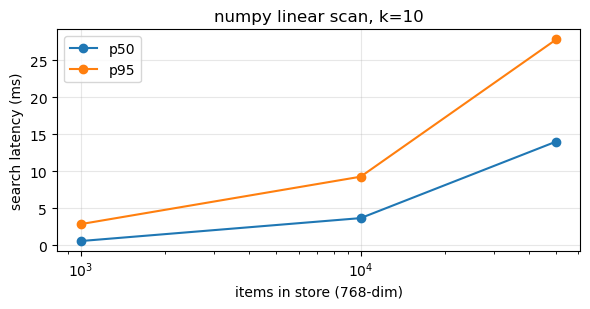

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(df["items"], df["p50_ms"], marker="o", label="p50")
ax.plot(df["items"], df["p95_ms"], marker="o", label="p95")
ax.set_xscale("log"); ax.set_xlabel("items in store (768-dim)"); ax.set_ylabel("search latency (ms)")
ax.set_title("numpy linear scan, k=10"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

## Takeaways

- **Retrieval is cheap.** The scan over a whole topic is well under a millisecond at a few hundred chunks and around 10 ms median at 50k. The store is a single numpy array; nothing else to run.
- **The embedder is the cost.** Every prompt needs one embedding. On CPU that is 50 ms to a couple of seconds depending on machine load; on a GPU or a cloud embedder it is tens of milliseconds. The scan does not change.
- **Updates are incremental.** Re-running `add_docs` after an edit embeds only the changed chunks. That makes "keep the topic store current while I work" practical.
- **Hooking up an LLM is one string.** `context_for(prompt).prompt` is the context block; prepend it and ask.

In [11]:
store.close()
print(store.memory.stats()["counters"])

{'embed.calls': 3, 'embed.items': 39, 'upsert.added': 37, 'search_vector.calls': 5, 'upsert.skipped_text_unchanged': 72, 'upsert.updated': 2}
